### Evaluation metrics

In [449]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [450]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [451]:
df.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges            str
churn                   str
dtype: object

In [452]:
categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)
for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

df.churn = (df.churn == 'yes').astype(int)

In [453]:
df

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-vhveg,female,0,yes,no,1,no,no_phone_service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic_check,29.85,29.85,0
1,5575-gnvde,male,0,no,no,34,yes,no,dsl,yes,...,yes,no,no,no,one_year,no,mailed_check,56.95,1889.50,0
2,3668-qpybk,male,0,no,no,2,yes,no,dsl,yes,...,no,no,no,no,month-to-month,yes,mailed_check,53.85,108.15,1
3,7795-cfocw,male,0,no,no,45,no,no_phone_service,dsl,yes,...,yes,yes,no,no,one_year,no,bank_transfer_(automatic),42.30,1840.75,0
4,9237-hqitu,female,0,no,no,2,yes,no,fiber_optic,no,...,no,no,no,no,month-to-month,yes,electronic_check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-resvb,male,0,yes,yes,24,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,yes,mailed_check,84.80,1990.50,0
7039,2234-xaduh,female,0,yes,yes,72,yes,yes,fiber_optic,no,...,yes,no,yes,yes,one_year,yes,credit_card_(automatic),103.20,7362.90,0
7040,4801-jzazl,female,0,yes,yes,11,no,no_phone_service,dsl,yes,...,no,no,no,no,month-to-month,yes,electronic_check,29.60,346.45,0
7041,8361-ltmkd,male,1,yes,no,4,yes,yes,fiber_optic,no,...,no,no,no,no,month-to-month,yes,mailed_check,74.40,306.60,1


In [454]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']

In [455]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [456]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

model = LogisticRegression()
model.fit(X_train, y_train)

d:\Projects\ML-Zoomcamp\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [457]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:, 1]

In [458]:
churn_decision = (y_pred >= 0.5)
churn_decision

array([False, False, False, ..., False,  True,  True], shape=(1409,))

In [459]:
(y_val == churn_decision).mean()

np.float64(0.8026969481902059)

#### Accuracy and dummy model

In [460]:
len(y_val)

1409

In [461]:
(y_val == churn_decision).sum()

np.int64(1131)

In [462]:
1131 / 1409

0.8026969481902059

In [463]:
1409 - 1131

278

In [464]:
thresholds = np.linspace(0, 1, 101)

In [465]:
max_accuracy = 0
best_threshold = 0
scores = []
for t in thresholds:
    churn_decision = (y_pred >= t)
    accuracy = (y_val == churn_decision).mean()
    if accuracy > max_accuracy:
        max_accuracy = accuracy
        best_threshold = t
    scores.append(accuracy)
    print(t, accuracy)
print('Best threshold:', best_threshold)
print('Max accuracy:', max_accuracy)

0.0 0.2739531582682754
0.01 0.3520227111426544
0.02 0.41022001419446413
0.03 0.45422285308729593
0.04 0.48899929027679206
0.05 0.5102909865152591
0.06 0.5259048970901349
0.07 0.5351312987934705
0.08 0.5550035486160397
0.09 0.5762952448545068
0.1 0.5919091554293825
0.11 0.6103619588360539
0.12 0.6238466997870831
0.13 0.6430092264017033
0.14 0.6557842441447835
0.15 0.6671398154719659
0.16 0.6756564939673527
0.17 0.687721788502484
0.18 0.6976579134137686
0.19 0.7040454222853088
0.2 0.7097232079489
0.21 0.7182398864442867
0.22 0.7267565649396736
0.23 0.7310149041873669
0.24 0.7352732434350603
0.25 0.7388218594748048
0.26 0.7423704755145494
0.27 0.7494677075940384
0.28 0.7544357700496807
0.29 0.758694109297374
0.3 0.7601135557132718
0.31 0.7615330021291696
0.32 0.7629524485450674
0.33 0.7650816181689141
0.34 0.7693399574166075
0.35000000000000003 0.7721788502484032
0.36 0.7735982966643009
0.37 0.7743080198722498
0.38 0.7792760823278921
0.39 0.7778566359119943
0.4 0.7849538679914834
0.410000

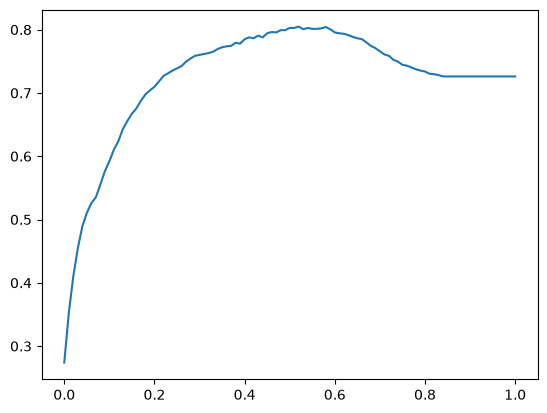

In [466]:
plt.plot(thresholds, scores)

In [467]:
from sklearn.metrics import accuracy_score

In [468]:
churn_decision = (y_pred >= 0.5)

In [469]:
accuracy_score(y_val, churn_decision)

0.8026969481902059

In [470]:
from collections import Counter
Counter(y_pred >= 1.0)

Counter({np.False_: 1409})

In [471]:
y_val.mean()

np.float64(0.2739531582682754)

In [472]:
1 - y_val.mean()

np.float64(0.7260468417317246)

#### Confusion table

In [473]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

In [474]:
t = 0.5
predicted_positive = (y_pred >= t)
predicted_negative = (y_pred < t)

In [475]:
tp = (actual_positive & predicted_positive).sum()
tn = (actual_negative & predicted_negative).sum()
fp = (actual_negative & predicted_positive).sum()
fn = (actual_positive & predicted_negative).sum()

In [476]:
print(tp, tn, fp, fn)

210 921 102 176


In [477]:
print(sum([tp, tn, fp, fn]))

1409


In [478]:
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])

In [479]:
print(confusion_matrix)

[[921 102]
 [176 210]]


In [480]:
confusion_matrix / confusion_matrix.sum()

array([[0.65365507, 0.07239177],
       [0.12491128, 0.14904187]])

#### Precision and recall

In [481]:
(tn + tp) / confusion_matrix.sum()

np.float64(0.8026969481902059)

In [482]:
precision = tp / (tp + fp)

In [483]:
precision

np.float64(0.6730769230769231)

In [484]:
tp + fp

np.int64(312)

In [485]:
recall = tp / (tp + fn)

In [486]:
recall

np.float64(0.5440414507772021)

In [487]:
1 - recall

np.float64(0.4559585492227979)

#### Precision and recall for different thresholds

In [488]:
thresholds = [0.1 * i for i in range(0, 10)]
thresholds = [round(t, 1) for t in thresholds]

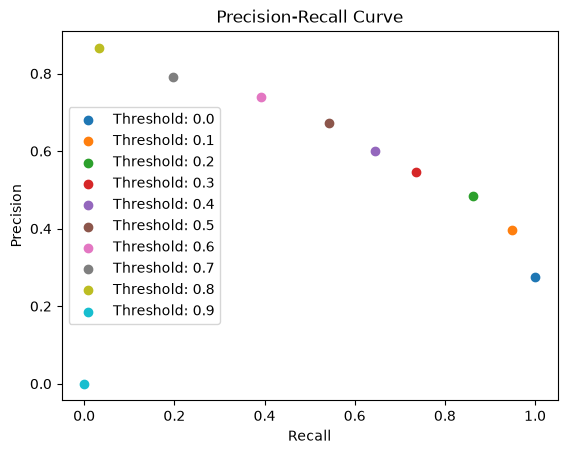

In [489]:
for t in thresholds:
    predicted_positive_t = (y_pred >= t)
    predicted_negative_t = (y_pred < t)
    tp_t = (actual_positive & predicted_positive_t).sum()
    tn_t = (actual_negative & predicted_negative_t).sum()
    fp_t = (actual_negative & predicted_positive_t).sum()
    fn_t = (actual_positive & predicted_negative_t).sum()
    precision_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    recall_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    plt.scatter(recall_t, precision_t, label=f"Threshold: {t}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

#### F-Score

In [490]:
f_score = 2 * (precision * recall) / (precision + recall)

In [491]:
f_score

np.float64(0.6017191977077365)

#### Precision and recall for model that always predicts false

In [492]:
predicted_positive_f = (y_pred >= 1)
predicted_negative_f = (y_pred < 1)

In [493]:
tp_f = (predicted_positive_f & actual_positive).sum()
tn_f = (predicted_negative_f & actual_negative).sum()
fp_f = (predicted_positive_f & actual_negative).sum()
fn_f = (predicted_negative_f & actual_positive).sum()

In [494]:
precision_f = tp_f / (tp_f + fp_f)

C:\Users\wicho\AppData\Local\Temp\ipykernel_14476\398389899.py:1: RuntimeWarning: invalid value encountered in scalar divide
  precision_f = tp_f / (tp_f + fp_f)


Precision does not exist

In [495]:
recall_f = tp_f / (tp_f + fn_f)

In [496]:
recall_f

np.float64(0.0)

Recall is always zero since tp will always be zero.

#### ROC Curves

In [497]:
tpr = tp / (tp + fn)

In [498]:
fpr = fp / (fp + tn)

In [499]:
print(tpr, fpr)

0.5440414507772021 0.09970674486803519


In [500]:
thresholds = np.linspace(0, 1, 101)

In [501]:
scores = []
for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    predicted_positive = (y_pred >= t)
    predicted_negative = (y_pred < t)

    tp = (actual_positive & predicted_positive).sum()
    tn = (actual_negative & predicted_negative).sum()
    fp = (actual_negative & predicted_positive).sum()
    fn = (actual_positive & predicted_negative).sum()

    scores.append((t, tp, fp, fn, tn))

In [502]:
scores

[(np.float64(0.0), np.int64(386), np.int64(1023), np.int64(0), np.int64(0)),
 (np.float64(0.01), np.int64(385), np.int64(912), np.int64(1), np.int64(111)),
 (np.float64(0.02), np.int64(384), np.int64(829), np.int64(2), np.int64(194)),
 (np.float64(0.03), np.int64(383), np.int64(766), np.int64(3), np.int64(257)),
 (np.float64(0.04), np.int64(381), np.int64(715), np.int64(5), np.int64(308)),
 (np.float64(0.05), np.int64(379), np.int64(683), np.int64(7), np.int64(340)),
 (np.float64(0.06), np.int64(377), np.int64(659), np.int64(9), np.int64(364)),
 (np.float64(0.07), np.int64(372), np.int64(641), np.int64(14), np.int64(382)),
 (np.float64(0.08), np.int64(371), np.int64(612), np.int64(15), np.int64(411)),
 (np.float64(0.09), np.int64(369), np.int64(580), np.int64(17), np.int64(443)),
 (np.float64(0.1), np.int64(366), np.int64(555), np.int64(20), np.int64(468)),
 (np.float64(0.11), np.int64(365), np.int64(528), np.int64(21), np.int64(495)),
 (np.float64(0.12), np.int64(365), np.int64(509), 

In [503]:
df_scores = pd.DataFrame(scores, columns=['threshold', 'tp', 'fp', 'fn', 'tn'])

In [504]:
df_scores

,threshold,tp,fp,fn,tn
0,0.00,386,1023,0,0
1,0.01,385,912,1,111
2,0.02,384,829,2,194
3,0.03,383,766,3,257
4,0.04,381,715,5,308
...,...,...,...,...,...
96,0.96,0,0,386,1023
97,0.97,0,0,386,1023
98,0.98,0,0,386,1023
99,0.99,0,0,386,1023


In [505]:
df_scores[::10]

,threshold,tp,fp,fn,tn
0,0.0,386,1023,0,0
10,0.1,366,555,20,468
20,0.2,333,356,53,667
30,0.3,284,236,102,787
40,0.4,249,166,137,857
50,0.5,210,102,176,921
60,0.6,151,53,235,970
70,0.7,76,20,310,1003
80,0.8,13,2,373,1021
90,0.9,0,0,386,1023


In [506]:
df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

In [507]:
df_scores[::10]

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,366,555,20,468,0.948187,0.542522
20,0.2,333,356,53,667,0.862694,0.347996
30,0.3,284,236,102,787,0.735751,0.230694
40,0.4,249,166,137,857,0.645078,0.162268
50,0.5,210,102,176,921,0.544041,0.099707
60,0.6,151,53,235,970,0.391192,0.051808
70,0.7,76,20,310,1003,0.196891,0.019550
80,0.8,13,2,373,1021,0.033679,0.001955
90,0.9,0,0,386,1023,0.000000,0.000000


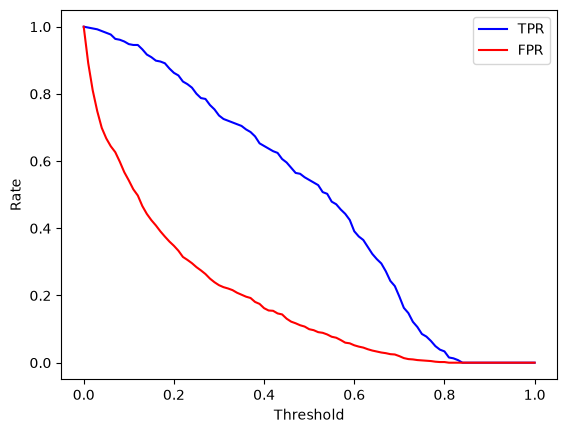

In [508]:
plt.plot(df_scores.threshold, df_scores.tpr, label='TPR', color='blue')
plt.plot(df_scores.threshold, df_scores.fpr, label='FPR', color='red')
plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.legend()
plt.show()

#### Random model

In [509]:
np.random.seed(1)
y_rand = np.random.uniform(0, 1, size=len(y_val))

In [510]:
y_rand.round(3)

array([0.417, 0.72 , 0.   , ..., 0.774, 0.334, 0.089], shape=(1409,))

In [511]:
((y_rand >= 0.5) == y_val).mean()

np.float64(0.5017743080198722)

In [512]:
def tpr_fpr_df(y_val, y_pred):
    thresholds = np.linspace(0, 1, 101)
    scores = []
    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)
        predicted_positive = (y_pred >= t)
        predicted_negative = (y_pred < t)

        tp = (actual_positive & predicted_positive).sum()
        tn = (actual_negative & predicted_negative).sum()
        fp = (actual_negative & predicted_positive).sum()
        fn = (actual_positive & predicted_negative).sum()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        scores.append((t, tp, fp, fn, tn, tpr, fpr))

    return pd.DataFrame(scores, columns=['threshold', 'tp', 'fp', 'fn', 'tn', 'tpr', 'fpr'])

In [513]:
df_rand = tpr_fpr_df(y_val, y_rand)

In [514]:
df_rand[::10]

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,347,923,39,100,0.898964,0.902248
20,0.2,307,822,79,201,0.795337,0.803519
30,0.3,276,724,110,299,0.715026,0.707722
40,0.4,237,624,149,399,0.613990,0.609971
50,0.5,202,518,184,505,0.523316,0.506354
60,0.6,161,409,225,614,0.417098,0.399804
70,0.7,121,302,265,721,0.313472,0.295210
80,0.8,78,206,308,817,0.202073,0.201369
90,0.9,40,101,346,922,0.103627,0.098729


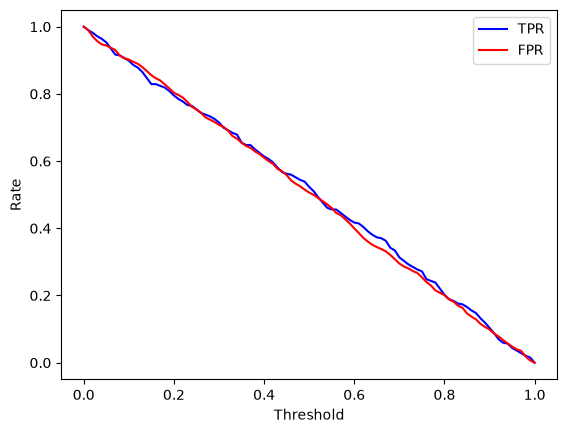

In [515]:
plt.plot(df_rand.threshold, df_rand.tpr, label='TPR', color='blue')
plt.plot(df_rand.threshold, df_rand.fpr, label='FPR', color='red')
plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.legend()
plt.show()

#### Ideal model

In [516]:
num_neg = (y_val == 0).sum()
num_pos = (y_val == 1).sum()
print(num_neg, num_pos)

1023 386


In [517]:
y_ideal = np.repeat([0, 1], [num_neg, num_pos])
y_ideal

array([0, 0, 0, ..., 1, 1, 1], shape=(1409,))

In [518]:
y_ideal_pred = np.linspace(0, 1, len(y_val))

In [519]:
1 - y_val.mean()

np.float64(0.7260468417317246)

In [520]:
((y_ideal_pred >= 0.726) == y_ideal).mean()

np.float64(1.0)

In [521]:
df_ideal = tpr_fpr_df(y_ideal, y_ideal_pred)

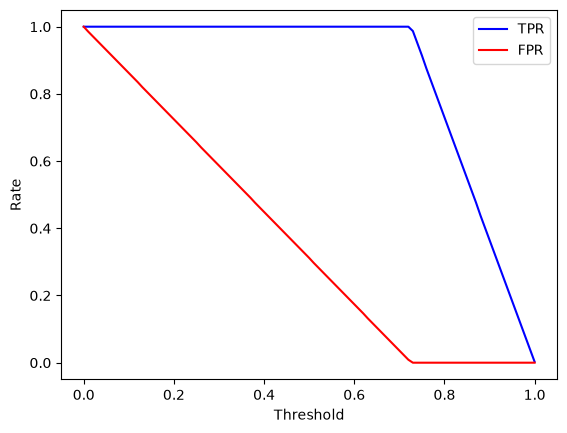

In [522]:
plt.plot(df_ideal.threshold, df_ideal.tpr, label='TPR', color='blue')
plt.plot(df_ideal.threshold, df_ideal.fpr, label='FPR', color='red')
plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.legend()
plt.show()

#### Putting everything together

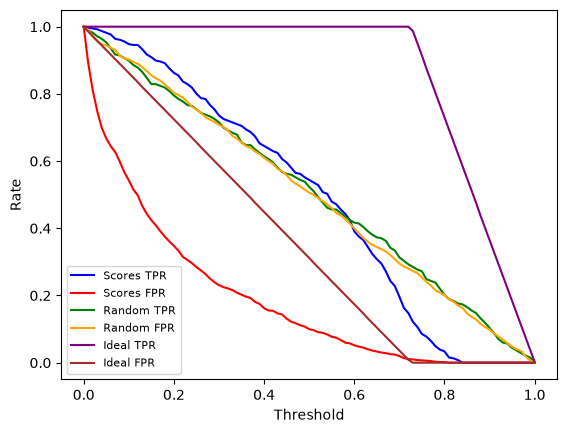

In [523]:
plt.plot(df_scores.threshold, df_scores.tpr, label='Scores TPR', color='blue')
plt.plot(df_scores.threshold, df_scores.fpr, label='Scores FPR', color='red')
plt.plot(df_rand.threshold, df_rand.tpr, label='Random TPR', color='green')
plt.plot(df_rand.threshold, df_rand.fpr, label='Random FPR', color='orange')
plt.plot(df_ideal.threshold, df_ideal.tpr, label='Ideal TPR', color='purple')
plt.plot(df_ideal.threshold, df_ideal.fpr, label='Ideal FPR', color='brown')
plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.legend(prop={'size': 8.2})
plt.show()

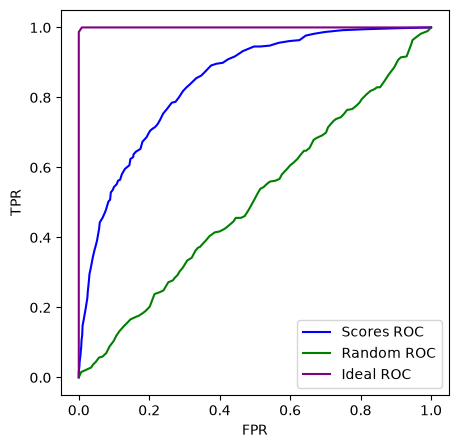

In [524]:
plt.figure(figsize=(5, 5))

plt.plot(df_scores.fpr, df_scores.tpr, label='Scores ROC', color='blue')
plt.plot(df_rand.fpr, df_rand.tpr, label='Random ROC', color='green')
plt.plot(df_ideal.fpr, df_ideal.tpr, label='Ideal ROC', color='purple')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

In [525]:
from sklearn.metrics import roc_curve, roc_auc_score

In [526]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)

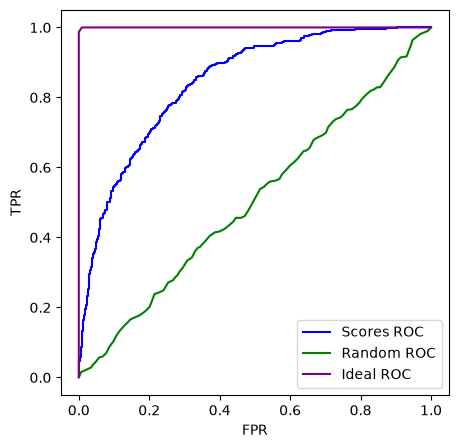

In [527]:
plt.figure(figsize=(5, 5))

plt.plot(fpr, tpr, label='Scores ROC', color='blue')
plt.plot(df_rand.fpr, df_rand.tpr, label='Random ROC', color='green')
plt.plot(df_ideal.fpr, df_ideal.tpr, label='Ideal ROC', color='purple')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

#### ROC AUC

In [528]:
from sklearn.metrics import auc

In [529]:
auc(fpr, tpr)

0.8438150517374987

In [530]:
auc(df_ideal.fpr, df_ideal.tpr)

0.9999430203759136

In [531]:
roc_auc_score(y_val, y_pred)

0.8438150517374987

In [532]:
neg = y_pred[y_val == 0]

In [533]:
neg

array([0.00896799, 0.20454216, 0.21215178, ..., 0.10782325, 0.31371096,
       0.1363222 ], shape=(1023,))

In [534]:
pos = y_pred[y_val == 1]

In [535]:
import random

In [536]:
n = 100000000
success = 0

for _ in range(n):
    pos_ind = random.randint(0, len(pos) - 1)
    neg_ind = random.randint(0, len(neg) - 1)
    if pos[pos_ind] > neg[neg_ind]:
        success += 1

print(success / n)

0.8437837


In [537]:
pos_ind = np.random.randint(0, len(pos), size = n)
neg_ind = np.random.randint(0, len(neg), size = n)

In [538]:
success = np.mean(pos[pos_ind] > neg[neg_ind])

In [539]:
success

np.float64(0.84387629)

#### Cross-validation

In [540]:
def train(df, y_train, C=1.0):
    dicts = df[categorical + numerical].to_dict(orient='records')
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)
    model = LogisticRegression(C=C, max_iter=10000)
    model.fit(X_train, y_train)

    return dv, model

In [541]:
dv, model = train(df_train, y_train)

In [542]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')
    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]
    return y_pred

In [543]:
y_pred = predict(df_val, dv, model)

In [544]:
from sklearn.model_selection import KFold

In [545]:
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
kfold.split(df_full_train)
train_idx, val_idx = next(kfold.split(df_full_train))

In [546]:
df_train = df_full_train.iloc[train_idx]
df_val = df_full_train.iloc[val_idx]

In [547]:
from tqdm.auto import tqdm

In [548]:
C_scores = []
n_splits = 5
for C in [0.001, 0.01, 0.1, 1, 5, 10]:
    scores = []
    for train_idx, val_idx in tqdm(KFold(n_splits=n_splits, shuffle=True, random_state=1).split(df_full_train)):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.churn.values
        y_val = df_val.churn.values

        del df_train['churn']
        del df_val['churn']

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc_score = roc_auc_score(y_val, y_pred)
        print(auc_score)
        scores.append(auc_score)
        print("Mean AUC:", np.mean(scores))
    C_scores.append((C, np.mean(scores), np.std(scores)))


0it [00:00, ?it/s]

0.8256313240338801
Mean AUC: 0.8256313240338801
0.8335092206330288
Mean AUC: 0.8295702723334544
0.8102428256070641
Mean AUC: 0.8231277900913243
0.8201880955426233
Mean AUC: 0.8223928664541491
0.8358421448966143
Mean AUC: 0.8250827221426421


0it [00:00, ?it/s]

0.8430305123595858
Mean AUC: 0.8430305123595858
0.8464959111375977
Mean AUC: 0.8447632117485917
0.8293196869355811
Mean AUC: 0.8396153701442549
0.8311356877917759
Mean AUC: 0.8374954495561351
0.8498556681622792
Mean AUC: 0.8399674932773639


0it [00:00, ?it/s]

0.8445376831958301
Mean AUC: 0.8445376831958301
0.8459206562044762
Mean AUC: 0.8452291697001532
0.8329440096327513
Mean AUC: 0.8411341163443525
0.8340694346741702
Mean AUC: 0.8393679459268069
0.8517853220796335
Mean AUC: 0.8418514211573722


0it [00:00, ?it/s]

0.8444003108539849
Mean AUC: 0.8444003108539849
0.8451633061846113
Mean AUC: 0.8447818085192982
0.8336343568131648
Mean AUC: 0.8410659912839203
0.8347728944170877
Mean AUC: 0.8394927170672122
0.8518363088701327
Mean AUC: 0.8419614354277962


0it [00:00, ?it/s]

0.8439842689043968
Mean AUC: 0.8439842689043968
0.8448529168322076
Mean AUC: 0.8444185928683022
0.8337346979731085
Mean AUC: 0.8408572945699043
0.8348008729295899
Mean AUC: 0.8393431891598258
0.8516598161337894
Mean AUC: 0.8418065145546185


0it [00:00, ?it/s]

0.8439175451955003
Mean AUC: 0.8439175451955003
0.8448073930605217
Mean AUC: 0.8443624691280109
0.8336142885811759
Mean AUC: 0.8407797422790658
0.8347569066956577
Mean AUC: 0.8392740333832138
0.8520284898497066
Mean AUC: 0.8418249246765124


In [549]:
print('%.3f ± %.3f' % (np.mean(scores), np.std(scores)))

0.842 ± 0.007


In [550]:
for C, mean_auc, std_auc in C_scores:
    print(f"C={C}: {mean_auc:.3f} ± {std_auc:.3f}")

C=0.001: 0.825 ± 0.009
C=0.01: 0.840 ± 0.008
C=0.1: 0.842 ± 0.007
C=1: 0.842 ± 0.007
C=5: 0.842 ± 0.007
C=10: 0.842 ± 0.007


In [551]:
dv, model = train(df_full_train, df_full_train.churn, C=1.0)
y_pred = predict(df_test, dv, model)
auc_score = roc_auc_score(y_test, y_pred)

In [552]:
auc_score

0.8584573759303195